# Spatial data processing 

## Make boundary of Europe

Done — saved to data/processed/spatial_data/europe_boundary.gpkg


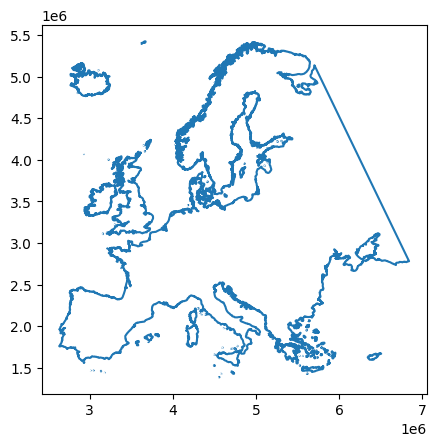

In [6]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import box, MultiPolygon, Polygon

# ── 1. Load Natural Earth 1:10m countries ────────────────────────────────────
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
)

# ── 2. European countries — match on ISO_A2, ISO_A3, or NAME ─────────────────
EUROPE_ISO2 = {
    "AL", "AD", "AT", "BY", "BE", "BA", "BG", "HR", "CY", "CZ",
    "DK", "EE", "FI", "FR", "DE", "GR", "HU", "IS", "IE", "IT",
    "LV", "LI", "LT", "LU", "MT", "MD", "MC", "ME", "NL",
    "MK", "PL", "PT", "RO", "RU", "SM", "RS", "SK", "SI",
    "ES", "SE", "CH", "UA", "GB", "VA",
    # Turkey removed
}
EUROPE_ISO3 = {"FRA", "NOR", "XKX"}

EUROPE_NAMES = {"France", "Norway", "Kosovo"}  # name-based fallback

europe = world[
    world["ISO_A2"].isin(EUROPE_ISO2)
    | world["ISO_A3"].isin(EUROPE_ISO3)
    | world["NAME"].isin(EUROPE_NAMES)
].copy()

# ── 3. Clip Russia ────────────────────────────────────────────────────────────
RUSSIA_EAST_MERIDIAN = 42

russia_clip_box = box(-30, 30, RUSSIA_EAST_MERIDIAN, 82)
russia_row = europe[europe["ISO_A2"] == "RU"].copy()
russia_clipped = russia_row.copy()
russia_clipped["geometry"] = russia_row.intersection(russia_clip_box)

europe = europe[europe["ISO_A2"] != "RU"]
europe = gpd.GeoDataFrame(
    pd.concat([europe, russia_clipped], ignore_index=True),
    crs="EPSG:4326"
)

# FIX: use a western bound of -30 to exclude the Pacific-side wrap-around chunk
russia_clip_box = box(-30, 30, RUSSIA_EAST_MERIDIAN, 82)

russia_row = europe[europe["ISO_A2"] == "RU"].copy()
russia_clipped = russia_row.copy()
russia_clipped["geometry"] = russia_row.intersection(russia_clip_box)

europe = europe[europe["ISO_A2"] != "RU"]
europe = gpd.GeoDataFrame(
    pd.concat([europe, russia_clipped], ignore_index=True),
    crs="EPSG:4326"
)

# ── 4. Reproject to LAEA Europe ───────────────────────────────────────────────
europe = europe.to_crs("EPSG:3035")

# ── 5. Dissolve to single polygon ────────────────────────────────────────────
europe_dissolved = europe.dissolve().geometry.iloc[0]

# ── 6. Clip to European longitude/latitude extent BEFORE buffering ────────────
# This removes any overseas territories regardless of size
# Bounds: ~25°W to 50°E, 34°N to 72°N — adjust as needed
EUROPE_BOUNDS_4326 = box(-25, 34, 50, 72)

# We need to clip in WGS84, so work on the pre-reprojected data
# Rebuild: re-dissolve in 4326, clip, then reproject

europe_4326 = europe.to_crs("EPSG:4326")  # europe is still in scope from step 4
europe_dissolved_4326 = europe_4326.dissolve().geometry.iloc[0]
europe_clipped_4326 = europe_dissolved_4326.intersection(EUROPE_BOUNDS_4326)

# Reproject clipped geometry to 3035
europe_clipped_gdf = gpd.GeoDataFrame(
    geometry=[europe_clipped_4326], crs="EPSG:4326"
).to_crs("EPSG:3035")

europe_boundary = europe_clipped_gdf.geometry.iloc[0]

# ── 7. Save ───────────────────────────────────────────────────────────────────
europe_boundary_gdf = gpd.GeoDataFrame(geometry=[europe_boundary], crs="EPSG:3035")
europe_boundary_gdf.to_file("../../data/processed/spatial_data/europe_boundary.gpkg", driver="GPKG")

europe_boundary_gdf.boundary.plot()
print("Done — saved to data/processed/spatial_data/europe_boundary.gpkg")

### Rasterize

In [7]:
"""
Rasterize Europe boundary polygon to a 10 km x 10 km raster.

Input:  data/processed/spatial_data/europe_boundary.gpkg
Output: data/processed/spatial_data/europe_boundary_10km.tif

Assumes the boundary is in EPSG:3035 (ETRS89/LAEA Europe), which uses
metres as units — so 10 km = 10,000 m pixel size.
"""

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize

# ── Config ────────────────────────────────────────────────────────────────────

INPUT_PATH  = "../../data/processed/spatial_data/europe_boundary.gpkg"
OUTPUT_PATH = "../../data/processed/spatial_data/europe_boundary_10km.tif"
PIXEL_SIZE  = 10_000          # 10 km in metres (assumes projected CRS)
NODATA      = 0
BURN_VALUE  = 1               # pixel value inside the boundary

# ── Load boundary ─────────────────────────────────────────────────────────────

gdf = gpd.read_file(INPUT_PATH)
print(f"CRS detected: {gdf.crs}")
print(f"  → If this is not EPSG:3035, reproject before running.")

# Ensure the geometry is in a metre-based CRS so PIXEL_SIZE is meaningful.
# Uncomment the next line if you need to reproject:
# gdf = gdf.to_crs("EPSG:3035")

bounds = gdf.total_bounds          # (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = bounds
print(f"Bounds (m): {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")

# ── Compute raster dimensions ─────────────────────────────────────────────────

width  = int(np.ceil((maxx - minx) / PIXEL_SIZE))
height = int(np.ceil((maxy - miny) / PIXEL_SIZE))
print(f"Raster size: {width} cols × {height} rows  ({width * height / 1e6:.2f} M pixels)")

# Affine transform: top-left corner, positive x / negative y
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# ── Rasterize ─────────────────────────────────────────────────────────────────

shapes = ((geom, BURN_VALUE) for geom in gdf.geometry if geom is not None)

raster = rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=NODATA,
    dtype="uint8",
    all_touched=False,   # True = include pixels touched by boundary edge
)

# ── Write GeoTIFF ─────────────────────────────────────────────────────────────

profile = {
    "driver":    "GTiff",
    "dtype":     "uint8",
    "width":     width,
    "height":    height,
    "count":     1,
    "crs":       gdf.crs,
    "transform": transform,
    "nodata":    NODATA,
    "compress":  "lzw",   # lossless, keeps file small
    "tiled":     True,
    "blockxsize": 256,
    "blockysize": 256,
}

with rasterio.open(OUTPUT_PATH, "w", **profile) as dst:
    dst.write(raster, 1)

print(f"\nDone — saved to {OUTPUT_PATH}")
print(f"  Pixels inside boundary : {raster.sum():,}")
print(f"  Total pixels           : {raster.size:,}")

CRS detected: EPSG:3035
  → If this is not EPSG:3035, reproject before running.
Bounds (m): 2635415, 1385618, 6840057, 5424004
Raster size: 421 cols × 404 rows  (0.17 M pixels)

Done — saved to ../../data/processed/spatial_data/europe_boundary_10km.tif
  Pixels inside boundary : 73,208
  Total pixels           : 170,084


### Plot raster

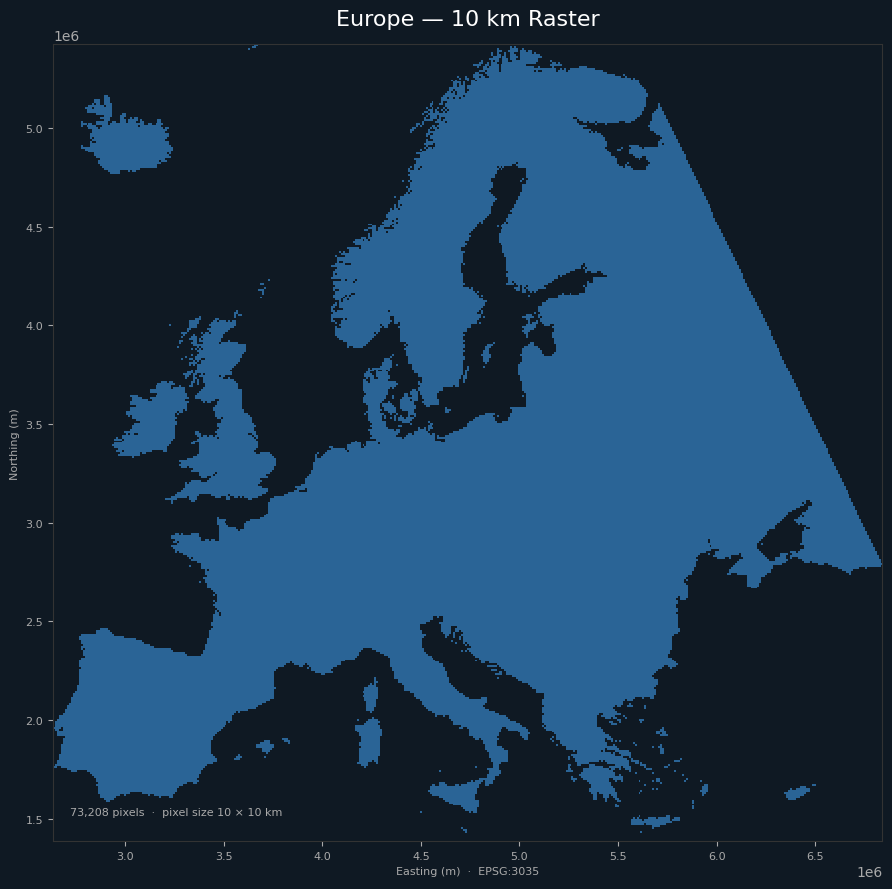

In [8]:
"""
Visualize the Europe boundary raster (europe_boundary_10km.tif).
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

INPUT_PATH = "../../data/processed/spatial_data/europe_boundary_10km.tif"

# ── Load raster ───────────────────────────────────────────────────────────────

with rasterio.open(INPUT_PATH) as src:
    data      = src.read(1).astype(float)
    bounds    = src.bounds
    crs       = src.crs
    nodata    = src.nodata

# Mask nodata / background pixels
if nodata is not None:
    data = np.where(data == nodata, np.nan, data)

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 9), facecolor="#0f1923")
ax.set_facecolor("#0f1923")

# Extent for correct axis labels (in CRS units, metres)
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Land: solid colour; background: transparent (NaN → transparent via cmap)
cmap = mcolors.ListedColormap(["#2a6496"])   # single colour for value=1
cmap.set_bad(color="#0f1923")                # NaN = background colour

ax.imshow(
    data,
    extent=extent,
    origin="upper",
    cmap=cmap,
    interpolation="nearest",
    vmin=0.5, vmax=1.5,
)

# ── Formatting ────────────────────────────────────────────────────────────────

ax.set_title("Europe — 10 km Raster", color="white", fontsize=16, pad=14)
ax.set_xlabel(f"Easting (m)  ·  {crs}", color="#aaaaaa", fontsize=8)
ax.set_ylabel("Northing (m)", color="#aaaaaa", fontsize=8)

ax.tick_params(colors="#aaaaaa", labelsize=8)
for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

# Pixel-count annotation
n_land = int(np.nansum(data))
ax.text(
    0.02, 0.03,
    f"{n_land:,} pixels  ·  pixel size 10 × 10 km",
    transform=ax.transAxes,
    color="#aaaaaa", fontsize=8,
    va="bottom",
)

plt.tight_layout()
plt.show()

## Agricultural data - SPAM

### SPAM - crop area (hectares)

In [14]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from pathlib import Path

# ── Load boundary in WGS84 to match SPAM's CRS ───────────────────────────────
boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg").to_crs("EPSG:4326")

# ── File paths ────────────────────────────────────────────────────────────────
data_dir = Path("../../data/raw_data/spatial_data/crops_SPAM")
out_dir  = Path("../../data/processed/spatial_data/crops_SPAM")
out_dir.mkdir(parents=True, exist_ok=True)

crops = ["COTT", "OFIB", "OPUL"]

# ── Crop each file ────────────────────────────────────────────────────────────
for crop in crops:
    in_path  = data_dir / f"spam2020_V2r2_global_A_{crop}_A.tif"
    out_path = out_dir  / f"spam2020_V2r2_europe_{crop}.tif"

    with rasterio.open(in_path) as src:
        out_image, out_transform = mask(
            src, boundary.geometry, crop=True, nodata=src.nodata
        )
        out_meta = src.meta.copy()
        out_meta.update({
            "height":    out_image.shape[1],
            "width":     out_image.shape[2],
            "transform": out_transform,
        })
        with rasterio.open(out_path, "w", **out_meta) as dst:
            dst.write(out_image)

    print(f"Saved: {out_path}")

Saved: ../../data/processed/spatial_data/crops_SPAM/spam2020_V2r2_europe_COTT.tif
Saved: ../../data/processed/spatial_data/crops_SPAM/spam2020_V2r2_europe_OFIB.tif
Saved: ../../data/processed/spatial_data/crops_SPAM/spam2020_V2r2_europe_OPUL.tif


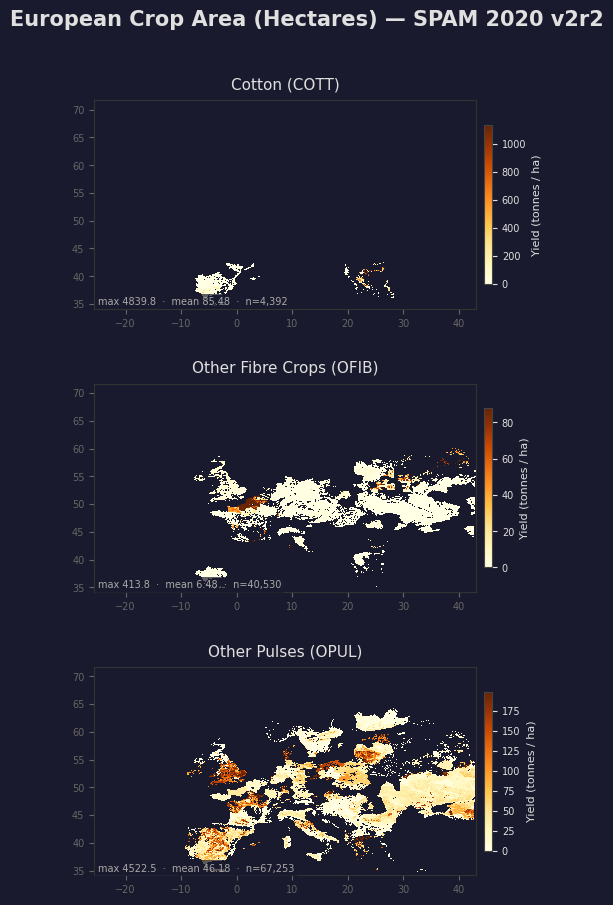

In [20]:
"""
Visualize three crop yield GeoTIFFs side by side.

Crops:
  COTT  — Cotton
  OFIB  — Other fibre crops
  OPUL  — Other pulses
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

# ── Config ────────────────────────────────────────────────────────────────────

FILES = {
    "Cotton (COTT)":           "../../data/processed/spatial_data/crops/spam2020_V2r2_europe_COTT.tif",
    "Other Fibre Crops (OFIB)":"../../data/processed/spatial_data/crops/spam2020_V2r2_europe_OFIB.tif",
    "Other Pulses (OPUL)":     "../../data/processed/spatial_data/crops/spam2020_V2r2_europe_OPUL.tif",
}

CMAP      = "YlOrBr"   # perceptually uniform, good for yield data
BG_COLOR  = "#1a1a2e"
TEXT_COLOR = "#e0e0e0"

# ── Load rasters ──────────────────────────────────────────────────────────────

datasets = {}
for label, path in FILES.items():
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds
        crs    = src.crs

    # Mask nodata and zero/negative values
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data <= 0, np.nan, data)

    datasets[label] = {"data": data, "bounds": bounds, "crs": crs}

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(5, 9), facecolor=BG_COLOR)
fig.suptitle(
    "European Crop Area (Hectares) — SPAM 2020 v2r2",
    color=TEXT_COLOR, fontsize=15, fontweight="bold", y=1.01
)

for ax, (label, ds) in zip(axes, datasets.items()):
    data   = ds["data"]
    bounds = ds["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Consistent colour scale per crop (0 → max), ignoring outliers
    vmax = np.nanpercentile(data, 98)   # clip top 2% so outliers don't wash out the map

    cmap = plt.get_cmap(CMAP).copy()
    cmap.set_bad(color=BG_COLOR)        # NaN → background

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, orientation="vertical")
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR, labelsize=7)
    cbar.outline.set_edgecolor("#444444")
    cbar.set_label("Yield (tonnes / ha)", color=TEXT_COLOR, fontsize=8)

    # Stats annotation
    valid = data[~np.isnan(data)]
    stats = (
        f"max {np.nanmax(data):.1f}  ·  "
        f"mean {np.nanmean(data):.2f}  ·  "
        f"n={len(valid):,}"
    )
    ax.text(
        0.01, 0.01, stats,
        transform=ax.transAxes,
        color="#aaaaaa", fontsize=7, va="bottom",
        bbox=dict(facecolor=BG_COLOR, edgecolor="none", alpha=0.7, pad=2),
    )

    ax.set_title(label, color=TEXT_COLOR, fontsize=11, pad=8)
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="#666666", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

### Eurostat - yield (tonnes per hectare)

In [27]:
"""
Preprocess Eurostat crop yield data (2024) and join to a Europe shapefile.

Steps:
  1. Download Europe country boundaries from Natural Earth (free, no account needed)
  2. Parse the three Eurostat Excel files, extracting 2024 yield values
  3. Join yield data to the shapefile by country name
  4. Save as a GeoPackage with three yield columns

Output: data/processed/spatial_data/europe_crop_yields_2024.gpkg

Dependencies: geopandas, pandas, openpyxl, requests
  pip install geopandas pandas openpyxl requests
"""

import io
import zipfile
import requests
import numpy as np
import pandas as pd
import geopandas as gpd

# ── Config ────────────────────────────────────────────────────────────────────

# Adjust paths to your Excel files
FILES = {
    "yield_cotton_t_ha":    "../../data/raw_data/spatial_data/crops_eurostat/cottonFiber_yield_nationalData_tonnesPerHectare.xlsx",
    "yield_hemp_t_ha":      "../../data/raw_data/spatial_data/crops_eurostat/hemp_yield_nationalData_tonnesPerHectare.xlsx",
    "yield_peas_t_ha":      "../../data/raw_data/spatial_data/crops_eurostat/peas_yield_nationalData_tonnesPerHectare.xlsx",
}

# Sheet 1 = peas/hemp; Sheet 3 = cotton (inside the peas file)
SHEET_MAP = {
    "yield_cotton_t_ha":  {"file": FILES["yield_cotton_t_ha"], "sheet": "Sheet 3"},
    "yield_hemp_t_ha":    {"file": FILES["yield_hemp_t_ha"],   "sheet": "Sheet 1"},
    "yield_peas_t_ha":    {"file": FILES["yield_peas_t_ha"],   "sheet": "Sheet 1"},
}

OUTPUT_PATH = "../../data/processed/spatial_data/crops/eurostat_crop_yields_2024.gpkg"
YEAR = "2024"

# ── 1. Download Europe shapefile (Natural Earth 1:10m cultural vectors) ───────

print("Downloading Europe country boundaries from Natural Earth …")
NE_URL = (
    "https://naciscdn.org/naturalearth/10m/cultural/"
    "ne_10m_admin_0_countries.zip"
)
resp = requests.get(NE_URL, timeout=60)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("ne_countries_10m")

world = gpd.read_file("ne_countries_10m/ne_10m_admin_0_countries.shp")

# Filter to Europe (sovereign states + dependent territories on the continent)
europe = world[world["CONTINENT"] == "Europe"].copy()
print(f"  → {len(europe)} European features loaded")

# ── 2. Parse Eurostat Excel files ─────────────────────────────────────────────

def parse_eurostat_sheet(filepath, sheet_name, col_name, year=YEAR):
    """
    Read a Eurostat crop yield sheet and return a tidy DataFrame with
    columns [country, <col_name>].

    Eurostat quirks handled:
      - Header rows before the data table (skip until 'GEO' row)
      - Flag codes after values (e.g. '1.5 e', '3.2 p') — strip them
      - Missing / suppressed values marked ':' → NaN
      - EU aggregate rows — dropped
    """
    raw = pd.read_excel(filepath, sheet_name=sheet_name, header=None, dtype=str)

    # Find the row where the GEO column label appears
    geo_row = None
    for i, row in raw.iterrows():
        if any(str(c).strip().startswith("GEO") for c in row):
            geo_row = i
            break
    if geo_row is None:
        raise ValueError(f"Could not find GEO header row in {filepath} / {sheet_name}")

    # The TIME header row is one above GEO
    time_row = geo_row - 1
    years    = raw.iloc[time_row].tolist()

    # Find which column corresponds to `year`
    year_cols = [j for j, v in enumerate(years) if str(v).strip() == str(year)]
    if not year_cols:
        raise ValueError(f"Year {year} not found in {filepath} / {sheet_name}")
    year_col = year_cols[0]

    # Data starts from geo_row + 1 (skip the "GEO (Labels)" label row itself)
    data = raw.iloc[geo_row + 1:].copy()
    data.columns = range(len(data.columns))

    # Column 0 = country name, year_col = value (may be followed by a flag col)
    df = data[[0, year_col]].copy()
    df.columns = ["country", "raw_value"]

    # Drop EU aggregate rows (long names containing "European Union")
    df = df[~df["country"].str.contains("European Union", na=True)]
    df = df[df["country"].notna() & (df["country"].str.strip() != "")]

    # Clean value: strip flag letters, convert ':' to NaN
    def clean_val(v):
        v = str(v).strip()
        if v in (":", "nan", ""):
            return np.nan
        # Remove trailing flag codes (single letters like e, p, b, u)
        parts = v.split()
        try:
            return float(parts[0])
        except ValueError:
            return np.nan

    df[col_name] = df["raw_value"].apply(clean_val)
    df = df[["country", col_name]].copy()
    df["country"] = df["country"].str.strip()
    return df

print(f"\nParsing Eurostat data for {YEAR} …")
df_cotton = parse_eurostat_sheet(
    FILES["yield_cotton_t_ha"], "Sheet 3", "yield_cotton_t_ha"
)
df_hemp   = parse_eurostat_sheet(
    FILES["yield_hemp_t_ha"],   "Sheet 1", "yield_hemp_t_ha"
)
df_peas   = parse_eurostat_sheet(
    FILES["yield_peas_t_ha"],   "Sheet 1", "yield_peas_t_ha"
)

# Merge all three on country
yields = (
    df_peas
    .merge(df_hemp,   on="country", how="outer")
    .merge(df_cotton, on="country", how="outer")
)
print(f"  → {len(yields)} country rows after merging")
print(yields.to_string(index=False))

# ── 3. Country name harmonisation ─────────────────────────────────────────────

# Eurostat uses full English names; Natural Earth uses slightly different ones.
NAME_MAP = {
    "Czechia":                  "Czechia",
    "Germany":                  "Germany",
    "Greece":                   "Greece",
    "Bosnia and Herzegovina":   "Bosnia and Herz.",
    "North Macedonia":          "North Macedonia",
    "Kosovo*":                  "Kosovo",
    "Türkiye":                  "Turkey",
}

yields["ne_name"] = yields["country"].replace(NAME_MAP)

# Natural Earth name column is NAME_LONG or SOVEREIGNT — use NAME for matching
europe["ne_name"] = europe["NAME"]

# ── 4. Spatial join ───────────────────────────────────────────────────────────

result = europe.merge(
    yields[["ne_name", "yield_peas_t_ha", "yield_hemp_t_ha", "yield_cotton_t_ha"]],
    on="ne_name",
    how="left",
)

matched = result[result["yield_peas_t_ha"].notna() |
                 result["yield_hemp_t_ha"].notna() |
                 result["yield_cotton_t_ha"].notna()]
print(f"\nCountries with at least one yield value: {len(matched)}")

unmatched_eurostat = set(yields["ne_name"]) - set(europe["ne_name"])
if unmatched_eurostat:
    print(f"  ⚠ Eurostat countries not matched to shapefile: {unmatched_eurostat}")
    print("    → Check NAME_MAP above and add missing entries.")

# ── 5. Save ───────────────────────────────────────────────────────────────────

# Keep only useful columns
keep_cols = ["NAME", "ISO_A2", "ISO_A3", "SOVEREIGNT",
             "yield_peas_t_ha", "yield_hemp_t_ha", "yield_cotton_t_ha", "geometry"]
keep_cols = [c for c in keep_cols if c in result.columns]
result = result[keep_cols]

result.to_file(OUTPUT_PATH, driver="GPKG", layer="europe_crop_yields_2024")
print(f"\nDone — saved to {OUTPUT_PATH}")
print(f"  Columns: {[c for c in result.columns if c != 'geometry']}")
print(f"  CRS: {result.crs}")

  → 51 European features loaded

Parsing Eurostat data for 2024 …


/Users/tsuitpy/miniconda3/envs/geo_env/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


  → 45 country rows after merging
               country  yield_peas_t_ha  yield_hemp_t_ha  yield_cotton_t_ha
                     :              NaN              NaN                NaN
               Albania              NaN              NaN                NaN
               Austria             2.04             3.91                NaN
               Belgium             2.87              NaN                NaN
Bosnia and Herzegovina             3.09              NaN                NaN
              Bulgaria             1.68              NaN               0.71
               Croatia             1.86              NaN                NaN
                Cyprus             2.16              NaN                NaN
               Czechia             1.67             0.90                NaN
               Denmark             2.97              NaN                NaN
               Estonia             2.37              NaN                NaN
               Finland             2.76              N

In [28]:
result.sort_values("NAME", ascending=True)

,NAME,ISO_A2,ISO_A3,SOVEREIGNT,yield_peas_t_ha,yield_hemp_t_ha,yield_cotton_t_ha,geometry
15,Albania,AL,ALB,Albania,NaN,NaN,NaN,"POLYGON ((20.56715 41.87318, 20.54172 41.86158..."
37,Andorra,AD,AND,Andorra,NaN,NaN,NaN,"POLYGON ((1.70701 42.50278, 1.6975 42.49446, 1..."
26,Austria,AT,AUT,Austria,2.04,3.91,NaN,"POLYGON ((16.94504 48.60417, 16.95434 48.5574,..."
2,Belarus,BY,BLR,Belarus,NaN,NaN,NaN,"POLYGON ((23.60624 51.5174, 23.60231 51.53078,..."
13,Belgium,BE,BEL,Belgium,2.87,NaN,NaN,"POLYGON ((2.5218 51.08754, 2.542 51.09687, 2.5..."
39,Bosnia and Herz.,BA,BIH,Bosnia and Herzegovina,3.09,NaN,NaN,"POLYGON ((17.65333 42.89094, 17.65284 42.89118..."
34,Bulgaria,BG,BGR,Bulgaria,1.68,NaN,0.71,"POLYGON ((26.33336 41.71304, 26.29491 41.71032..."
32,Croatia,HR,HRV,Croatia,1.86,NaN,NaN,"MULTIPOLYGON (((16.5153 46.50171, 16.52109 46...."
5,Czechia,CZ,CZE,Czechia,1.67,0.90,NaN,"POLYGON ((14.81039 50.85845, 14.83168 50.85798..."
18,Denmark,DK,DNK,Denmark,2.97,NaN,NaN,"MULTIPOLYGON (((8.66078 54.89631, 8.66879 54.9..."


### Yield raster maps (tonnes per year (per pixel))
Combining SPAM and Eurostat data 

In [36]:
"""
Compute total crop yield per pixel by combining:
  - SPAM rasters: crop AREA per pixel (hectares)
  - Eurostat GeoPackage: national yield (tonnes per hectare) per country polygon

Then reproject and snap the output to match a reference Europe 10km raster grid.

Method:
  1. Reproject Eurostat polygons to match SPAM raster CRS
  2. Rasterize the yield column → a yield-per-country raster at SPAM resolution
  3. Multiply pixel area (ha) × national yield (t/ha) → total yield (tonnes) per pixel
  4. Reproject/resample output to match the Europe 10km reference grid exactly
  5. Save output GeoTIFFs aligned to the reference grid

Note: SPAM data is 2020; Eurostat yields are 2024. Results reflect 2024 yield
rates applied to 2020 crop area distributions.

Outputs (one per crop, aligned to europe_boundary_10km.tif):
  spam2020_V2r2_europe_COTT_yield_tonnes_10km.tif
  spam2020_V2r2_europe_OFIB_yield_tonnes_10km.tif
  spam2020_V2r2_europe_OPUL_yield_tonnes_10km.tif
"""

import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import warnings

# ── Config ────────────────────────────────────────────────────────────────────

GPKG_PATH  = "../../data/processed/spatial_data/crops/eurostat_crop_yields_2024.gpkg"
SPAM_DIR   = "../../data/processed/spatial_data/crops"
OUT_DIR    = "../../data/processed/spatial_data/crops"
REF_PATH   = "../../data/processed/spatial_data/europe_boundary_10km.tif"

CROPS = {
    "COTT": "yield_cotton_t_ha",
    "OFIB": "yield_hemp_t_ha",
    "OPUL": "yield_peas_t_ha",
}

# ── Load reference grid metadata ──────────────────────────────────────────────

print("Loading reference grid …")
with rasterio.open(REF_PATH) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_width     = ref.width
    ref_height    = ref.height
    ref_nodata    = ref.nodata if ref.nodata is not None else -9999.0

print(f"  CRS:       {ref_crs}")
print(f"  Size:      {ref_width} × {ref_height} px")
print(f"  Transform: {ref_transform}\n")

# ── Load Eurostat polygons ────────────────────────────────────────────────────

print("Loading Eurostat country yield polygons …")
euro = gpd.read_file(GPKG_PATH)
print(f"  {len(euro)} features, CRS: {euro.crs}")
print(f"  Columns: {list(euro.columns)}\n")

# ── Process each crop ─────────────────────────────────────────────────────────

for crop_code, yield_col in CROPS.items():
    name_dict = {
        "COTT": "Cotton",
        "OFIB": "HempDust",    
        "OPUL": "Peas",
    }
    crop_name = name_dict[crop_code]
    spam_path = f"{SPAM_DIR}/spam2020_V2r2_europe_{crop_code}.tif"
    out_path  = f"{OUT_DIR}/yield_tonnes_perYear_10km_{crop_name}.tif"

    print(f"── {crop_code}  (yield column: {yield_col}) ──────────────────────")

    if yield_col not in euro.columns:
        print(f"  ⚠ Column '{yield_col}' not found in GeoPackage — skipping.")
        print(f"     Available columns: {[c for c in euro.columns if c != 'geometry']}\n")
        continue

    # ── 1. Open SPAM raster ───────────────────────────────────────────────────
    with rasterio.open(spam_path) as src:
        spam_data   = src.read(1).astype(np.float32)
        spam_crs    = src.crs
        spam_transform = src.transform
        width       = src.width
        height      = src.height
        spam_nodata = src.nodata

    if spam_nodata is not None:
        spam_data = np.where(spam_data == spam_nodata, np.nan, spam_data)
    spam_data = np.where(spam_data < 0, np.nan, spam_data)

    valid_pixels = int(np.sum(~np.isnan(spam_data)))
    print(f"  SPAM:     {width}×{height} px | {valid_pixels:,} valid pixels | CRS: {spam_crs}")

    # ── 2. Reproject Eurostat polygons to SPAM CRS ────────────────────────────
    euro_reproj = euro.to_crs(spam_crs)
    euro_valid  = euro_reproj[euro_reproj[yield_col].notna()].copy()
    print(f"  Eurostat: {len(euro_valid)} countries with data for {yield_col}")

    if len(euro_valid) == 0:
        warnings.warn(f"  ⚠ No yield data for {crop_code} — skipping.\n")
        continue

    # ── 3. Rasterize national yield values onto SPAM grid ────────────────────
    shapes = (
        (geom, float(val))
        for geom, val in zip(euro_valid.geometry, euro_valid[yield_col])
        if geom is not None and not np.isnan(float(val))
    )

    yield_raster = rasterize(
        shapes,
        out_shape=(height, width),
        transform=spam_transform,
        fill=np.nan,
        dtype=np.float32,
        all_touched=False,
    )

    covered = int(np.sum(~np.isnan(yield_raster)))
    print(f"  Yield raster: {covered:,} pixels covered by Eurostat polygons")

    # ── 4. Multiply: area (ha) × yield (t/ha) = total yield (tonnes) ─────────
    total_yield  = spam_data * yield_raster
    valid_output = int(np.sum(~np.isnan(total_yield) & (total_yield > 0)))
    total_tonnes = float(np.nansum(total_yield))
    print(f"  Output:   {valid_output:,} pixels with yield > 0")
    print(f"  Total {crop_code} yield (2024 rates × 2020 area): {total_tonnes:,.1f} tonnes")

    # ── 4b. For hemp: convert stalk yield to dust (5% of stalk weight) ───────
    if crop_code == "OFIB":
        total_yield = total_yield * 0.05
        print(f"  Hemp dust (5% of stalk): {float(np.nansum(total_yield)):,.1f} tonnes")

    # ── 5. Reproject to reference 10km grid ───────────────────────────────────
    # Replace NaN with nodata value for warp, then restore
    src_data = np.where(np.isnan(total_yield), -9999.0, total_yield).astype(np.float32)

    dst_data = np.full((ref_height, ref_width), -9999.0, dtype=np.float32)

    reproject(
        source      = src_data,
        destination = dst_data,
        src_transform  = spam_transform,
        src_crs        = spam_crs,
        src_nodata     = -9999.0,
        dst_transform  = ref_transform,
        dst_crs        = ref_crs,
        dst_nodata     = -9999.0,
        resampling     = Resampling.sum,   # preserve total yield when resampling
    )

    aligned_pixels = int(np.sum(dst_data > 0))
    print(f"  After alignment to 10km grid: {aligned_pixels:,} pixels with yield > 0")

    # ── 6. Write output GeoTIFF aligned to reference grid ────────────────────
    out_profile = {
        "driver":    "GTiff",
        "dtype":     "float32",
        "width":     ref_width,
        "height":    ref_height,
        "count":     1,
        "crs":       ref_crs,
        "transform": ref_transform,
        "nodata":    -9999.0,
        "compress":  "lzw",
        "tiled":     True,
        "blockxsize": 256,
        "blockysize": 256,
    }

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(dst_data, 1)
        dst.update_tags(
            crop         = crop_code,
            yield_column = yield_col,
            spam_year    = 2020,
            yield_year   = 2024,
            units        = "tonnes",
            note         = "pixel_area_ha * national_yield_t_ha, aligned to europe_boundary_10km.tif",
        )

    print(f"  Saved → {out_path}\n")

print("All crops processed.")

Loading reference grid …
  CRS:       EPSG:3035
  Size:      421 × 404 px
  Transform: | 9987.27, 0.00, 2635414.64|
| 0.00,-9996.01, 5424003.95|
| 0.00, 0.00, 1.00|

Loading Eurostat country yield polygons …
  51 features, CRS: EPSG:4326
  Columns: ['NAME', 'ISO_A2', 'ISO_A3', 'SOVEREIGNT', 'yield_peas_t_ha', 'yield_hemp_t_ha', 'yield_cotton_t_ha', 'geometry']

── COTT  (yield column: yield_cotton_t_ha) ──────────────────────
  SPAM:     826×450 px | 5,470 valid pixels | CRS: EPSG:4326
  Eurostat: 3 countries with data for yield_cotton_t_ha
  Yield raster: 11,395 pixels covered by Eurostat polygons
  Output:   4,069 pixels with yield > 0
  Total COTT yield (2024 rates × 2020 area): 436,139.5 tonnes
  After alignment to 10km grid: 3,764 pixels with yield > 0
  Saved → ../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_Cotton.tif

── OFIB  (yield column: yield_hemp_t_ha) ──────────────────────
  SPAM:     826×450 px | 59,486 valid pixels | CRS: EPSG:4326
  Eurostat: 11 cou

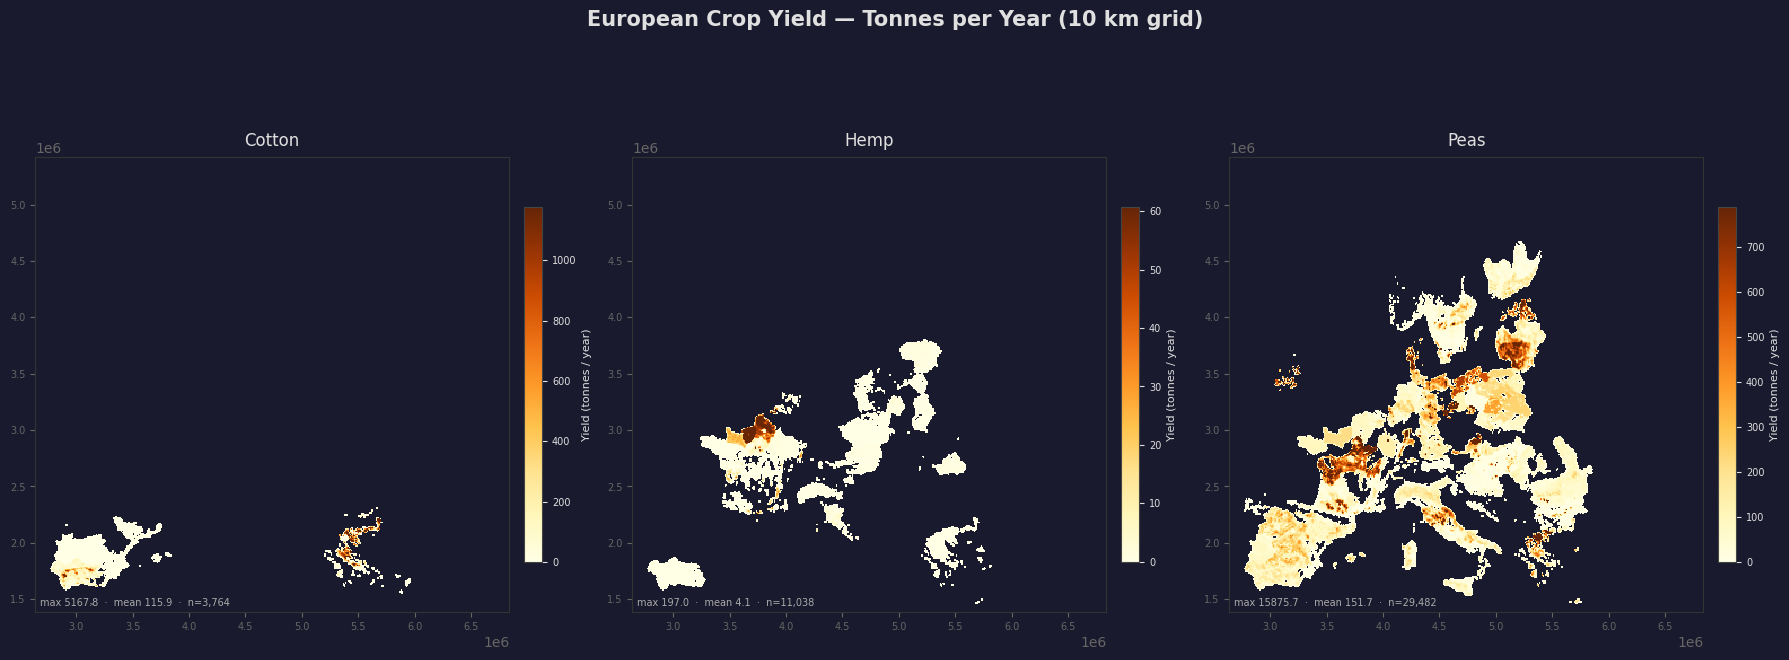

In [37]:
"""
Visualize yield (tonnes/year) rasters for Cotton, Hemp, and Peas side by side.
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────

FILES = {
    "Cotton":   "../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_Cotton.tif",
    "Hemp":     "../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_HempDust.tif",
    "Peas":     "../../data/processed/spatial_data/crops/yield_tonnes_perYear_10km_Peas.tif",
}

CMAP      = "YlOrBr"
BG_COLOR  = "#1a1a2e"
TEXT_COLOR = "#e0e0e0"

# ── Load rasters ──────────────────────────────────────────────────────────────

datasets = {}
for label, path in FILES.items():
    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        bounds = src.bounds

    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    data = np.where(data <= 0, np.nan, data)

    datasets[label] = {"data": data, "bounds": bounds}

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 7), facecolor=BG_COLOR)
fig.suptitle(
    "European Crop Yield — Tonnes per Year (10 km grid)",
    color=TEXT_COLOR, fontsize=15, fontweight="bold", y=1.01
)

for ax, (label, ds) in zip(axes, datasets.items()):
    data   = ds["data"]
    bounds = ds["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    vmax = np.nanpercentile(data, 98)

    cmap = plt.get_cmap(CMAP).copy()
    cmap.set_bad(color=BG_COLOR)

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=vmax,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR, labelsize=7)
    cbar.outline.set_edgecolor("#444444")
    cbar.set_label("Yield (tonnes / year)", color=TEXT_COLOR, fontsize=8)

    valid = data[~np.isnan(data)]
    stats = f"max {np.nanmax(data):.1f}  ·  mean {np.nanmean(data):.1f}  ·  n={len(valid):,}"
    ax.text(
        0.01, 0.01, stats,
        transform=ax.transAxes,
        color="#aaaaaa", fontsize=7, va="bottom",
        bbox=dict(facecolor=BG_COLOR, edgecolor="none", alpha=0.7, pad=2),
    )

    ax.set_title(label, color=TEXT_COLOR, fontsize=12, pad=8)
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="#666666", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

## Forestry data - S2BIOM

### Combine all country data on bark and sawdust into one

In [16]:
import pandas as pd
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────────
in_dir  = Path("../../data/raw_data/spatial_data/forestry_s2biom")
out_dir = Path("../../data/processed/spatial_data/forestry_s2biom")
out_dir.mkdir(parents=True, exist_ok=True)

# ── Biomass type IDs of interest ──────────────────────────────────────────────
# 4131 = bark, 4111 = sawdust conifers, 4112 = sawdust nonconifers
BARK_ID    = 4131
SAWDUST_IDS = [4111, 4112]

# ── Potentials and years to extract ───────────────────────────────────────────
POTENTIALS = ["TECH", "BASE", "UD01", "UD02", "UD03", "UD04",
              "UD05", "UD06", "UD07", "UD08", "UD09", "HIGH"]
YEARS      = [2012, 2020, 2030]

# ── Loop over all country files ───────────────────────────────────────────────
all_rows = []

for xlsx_path in sorted(in_dir.glob("data_*.xlsx")):
    country = xlsx_path.stem.replace("data_", "")  # e.g. "AT"
    print(f"Processing {country}...")

    xl = pd.ExcelFile(xlsx_path)

    for potential in POTENTIALS:
        for year in YEARS:
            sheet = f"dm_{potential}_{year}_kton"

            if sheet not in xl.sheet_names:
                continue  # not all potentials exist in all files

            df = pd.read_excel(xl, sheet_name=sheet, index_col=0)

            # Column headers are numeric type IDs — ensure they're integers
            df.columns = df.columns.astype(int)

            for nuts3_region, row in df.iterrows():
                bark    = row.get(BARK_ID, 0) or 0
                sawdust = sum(row.get(sid, 0) or 0 for sid in SAWDUST_IDS)

                all_rows.append({
                    "country":    country,
                    "nuts3":      nuts3_region,
                    "potential":  potential,
                    "year":       year,
                    "bark_kton":    bark,
                    "sawdust_kton": sawdust,
                })

# ── Assemble and save ─────────────────────────────────────────────────────────
result = pd.DataFrame(all_rows)
result = result.sort_values(["nuts3", "potential", "year"]).reset_index(drop=True)

out_path = out_dir / "wood_industry_residues_bark_sawdust_s2biom.csv"
result.to_csv(out_path, index=False)

print(f"\nDone — {len(result):,} rows saved to {out_path}")
print(result.head(10).to_string())

Processing AL...
Processing AT...
Processing BA...
Processing BE...
Processing BG...
Processing CY...
Processing CZ...
Processing DE...
Processing DK...
Processing EE...
Processing EL...
Processing ES...
Processing FI...
Processing FR...
Processing HR...
Processing HU...
Processing IE...
Processing IT...
Processing KS...
Processing LT...
Processing LU...
Processing LV...
Processing MD...
Processing ME...
Processing MK...
Processing MT...
Processing NL...
Processing PL...
Processing PT...
Processing RO...
Processing RS...
Processing SE...
Processing SI...
Processing SK...
Processing TR...
Processing UA...
Processing UK...

Done — 48,906 rows saved to ../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.csv
  country  nuts3 potential  year  bark_kton  sawdust_kton
0      AL  AL111      BASE  2012        0.0     10.188074
1      AL  AL111      BASE  2020        0.0     10.741223
2      AL  AL111      BASE  2030        0.0     12.915766
3      AL  AL

### Turn csv into spatial data (gpkg)

In [71]:
import geopandas as gpd
import pandas as pd

# ── Load NUTS3 geometries (2013 vintage) ──────────────────────────────────────
nuts3 = gpd.read_file(
    "https://gisco-services.ec.europa.eu/distribution/v2/nuts/geojson/"
    "NUTS_RG_10M_2013_4326_LEVL_3.geojson"
).to_crs("EPSG:3035")

# ── Clip to Europe boundary ───────────────────────────────────────────────────
boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg")
nuts3 = gpd.clip(nuts3, boundary)

# ── Load S2BIOM CSV ───────────────────────────────────────────────────────────
df = pd.read_csv("../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.csv")
df = df.rename(columns={"nuts3": "NUTS_ID"})

# ── Join all potentials/years onto geometry ───────────────────────────────────
gdf = nuts3.merge(df, on="NUTS_ID", how="left")

print(f"Total rows:         {len(gdf)}")
print(f"Matched (notna):    {gdf['bark_kton'].notna().sum()}")
print(f"Unmatched (NaN):    {gdf['bark_kton'].isna().sum()}")
print("\nUnmatched by country:")
print(gdf[gdf["bark_kton"].isna()]["CNTR_CODE"].value_counts().head(15))

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = "../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.gpkg"
gdf.to_file(out_path, driver="GPKG")
print(f"\nSaved: {out_path}")

Total rows:         44467
Matched (notna):    44418
Unmatched (NaN):    49

Unmatched by country:
CNTR_CODE
CH    26
NO    19
IS     2
ME     1
LI     1
Name: count, dtype: int64

Saved: ../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.gpkg


### Plot to check
[link to interactive map to check](https://s2biom.wenr.wur.nl/web/guest/biomass-supply#_48_INSTANCE_nYA0VqOhoRGM_%3Dhttps%253A%252F%252Fs2biom.wenr.wur.nl%252Fbiomasscostsupplyviewer%252Findex.html%253Fclassic%2526)

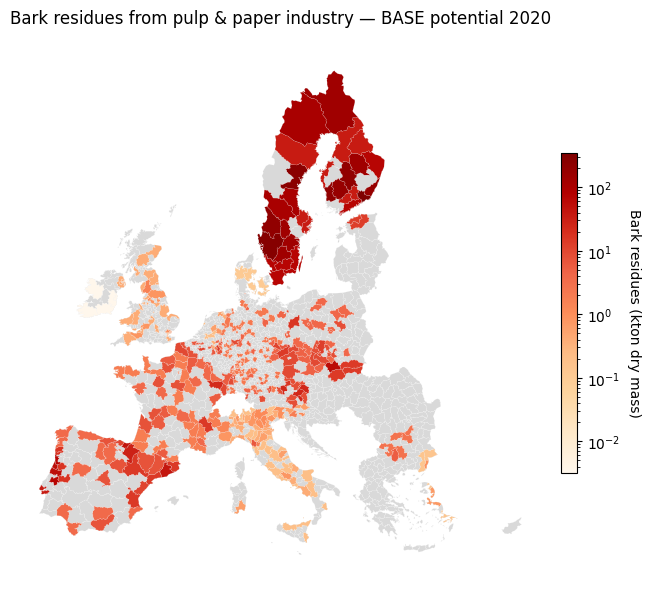

In [80]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

gdf = gpd.read_file("../../data/processed/spatial_data/forestry_s2biom/wood_industry_residues_bark_sawdust_s2biom.gpkg")
subset = gdf[(gdf.potential == "BASE") & (gdf.year == 2020)]

fig, ax = plt.subplots(figsize=(8, 6))

# Layer 1: all regions in grey (covers zeros and NaN)
subset.plot(ax=ax, color="#d9d9d9", linewidth=0.1, edgecolor="white")

# Layer 2: regions with bark > 0, colored by log scale
has_bark = subset[subset.bark_kton > 0]
norm = mcolors.LogNorm(vmin=has_bark.bark_kton.min(), vmax=has_bark.bark_kton.max())
has_bark.plot(ax=ax, column="bark_kton", cmap="OrRd",
              linewidth=0.1, edgecolor="white", norm=norm, legend=False)

sm = ScalarMappable(cmap="OrRd", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Bark residues (kton dry mass)", rotation=270, labelpad=15)

ax.set_title("Bark residues from pulp & paper industry — BASE potential 2020")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Seagrass

### Backup - abandoned datasets

#### Seagrass bed polygons - Europe
Abandoned because there are way less locations than the other seagrass density dataset. I would rather use the seagrass density points, create a standard buffer based on average size of sesagrass meadows, and get the areas from that. Otherwise there will be many locations missing. 

In [75]:
import geopandas as gpd
WFS_URL = (
    "https://ows.emodnet-seabedhabitats.eu/geoserver/emodnet_open/wfs?"
    "service=WFS&version=2.0.0&request=GetFeature"
    "&typeName=emodnet_open:seagrass_eov_poly_2025"
    "&outputFormat=application/json"
    "&bbox=-30,34,50,72,EPSG:4326" 
)
seagrass = gpd.read_file(WFS_URL)
print(f"Loaded {len(seagrass)} features")
# seagrass = seagrass[seagrass.det_date.str.startswith("202")] # keep only 2020s detections
seagrass.to_file("../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas.gpkg", driver="GPKG")

Loaded 623327 features


Check for overlaps in the geometry - there are (probably) none. I checked first 5000 polygons, and 0 overlaps were found. 

In [76]:
# ── Quick overlap check using spatial index ────────────────────────────────────
# This checks a sample to get a sense of whether overlaps exist at all
# before committing to a full dissolve

print("Checking for overlaps using spatial index...")
# seagrass = gpd.read_file("../../data/processed/spatial_data/seagrass/seagrass_emodnet_2025.gpkg")

# Use a sample first to get a quick answer without waiting hours
sample = seagrass.iloc[:5000].copy()
sample = sample.reset_index(drop=True)

overlap_count = 0
for idx, geom in enumerate(sample.geometry):
    # Find candidates via spatial index (bounding box overlap)
    candidates = sample.sindex.query(geom, predicate="intersects")
    # Remove self
    candidates = candidates[candidates != idx]
    if len(candidates) > 0:
        overlap_count += 1

print(f"Polygons with at least one neighbour intersecting (sample of 5000): {overlap_count}")

from shapely.geometry import shape

overlap_count = 0
for idx, geom in enumerate(sample.geometry):
    # Step 1: fast bounding box candidates via spatial index
    candidates = sample.sindex.query(geom, predicate="intersects")
    candidates = candidates[candidates != idx]
    
    if len(candidates) > 0:
        # Step 2: actual geometry intersection test on candidates only
        actual_overlaps = sample.iloc[candidates].geometry.apply(
            lambda g: geom.intersects(g) and not geom.touches(g)  
            # touches = shared boundary only (adjacent), not a true overlap
        )
        if actual_overlaps.any():
            overlap_count += 1

print(f"Polygons with actual geometric overlap (sample of 5000): {overlap_count}")

Checking for overlaps using spatial index...
Polygons with at least one neighbour intersecting (sample of 5000): 184
Polygons with actual geometric overlap (sample of 5000): 0


In [ ]:
# Step 1: Rasterize seagrass meadow polygons onto Europe base raster → meadow area [m²] per pixel

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from rasterio.enums import MergeAlg

# ── Paths ──────────────────────────────────────────────────────────────────────
SEAGRASS_PATH = "../../data/processed/spatial_data/seagrass/emodnet_seagrass_meadow_areas.gpkg"
BASE_RASTER_PATH = "../../data/processed/spatial_data/europe_boundary_10km.tif"
OUTPUT_PATH = "../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2.tif"

# ── Read base raster metadata ──────────────────────────────────────────────────
with rasterio.open(BASE_RASTER_PATH) as src:
    base_crs    = src.crs
    base_transform = src.transform
    base_width  = src.width
    base_height = src.height
    base_meta   = src.meta.copy()

print(f"Base raster CRS   : {base_crs}")
print(f"Base raster shape : {base_height} rows × {base_width} cols")

# ── Read & reproject seagrass polygons ────────────────────────────────────────
print("\nReading seagrass polygons...")
seagrass = gpd.read_file(SEAGRASS_PATH)
print(f"Loaded {len(seagrass):,} polygons (CRS: {seagrass.crs})")

print(f"Reprojecting to {base_crs}...")
seagrass = seagrass.to_crs(base_crs)

# ── Calculate area in m² (after reprojection to equal-area CRS) ───────────────
seagrass["area_m2"] = seagrass.geometry.area
print(f"Total seagrass area : {seagrass['area_m2'].sum() / 1e6:,.1f} km²")

# ── Rasterize: sum polygon areas per pixel ────────────────────────────────────
# MergeAlg.add accumulates area where multiple polygons fall in the same pixel
print("\nRasterizing in chunks...")

meadow_area_raster = np.zeros((base_height, base_width), dtype=np.float32)

CHUNK_SIZE = 50_000
n_chunks = int(np.ceil(len(seagrass) / CHUNK_SIZE))

for i in range(n_chunks):
    chunk = seagrass.iloc[i * CHUNK_SIZE : (i + 1) * CHUNK_SIZE]
    print(f"  Chunk {i+1}/{n_chunks}  ({len(chunk):,} polygons)")

    shapes = (
        (geom, float(area))
        for geom, area in zip(chunk.geometry, chunk["area_m2"])
        if geom is not None and not geom.is_empty
    )

    chunk_raster = rasterize(
        shapes=shapes,
        out_shape=(base_height, base_width),
        transform=base_transform,
        fill=0,
        dtype=np.float32,
        merge_alg=MergeAlg.add,
    )

    meadow_area_raster += chunk_raster

# ── Sanity checks ─────────────────────────────────────────────────────────────
pixel_area_m2 = abs(base_transform.a * base_transform.e)
print(f"\nPixel area          : {pixel_area_m2 / 1e6:.1f} km²")
print(f"Non-zero pixels     : {np.count_nonzero(meadow_area_raster):,}")
print(f"Max area per pixel  : {meadow_area_raster.max() / 1e6:.2f} km²")
print(f"Total rasterized area: {meadow_area_raster.sum() / 1e6:,.1f} km²")

# Flag pixels where rasterized area exceeds pixel area (should not happen without overlaps)
overfull = np.sum(meadow_area_raster > pixel_area_m2)
if overfull > 0:
    print(f"WARNING: {overfull} pixels exceed pixel area — possible overlaps or edge effects")
else:
    print("OK: no pixels exceed pixel area")

# ── Write output ───────────────────────────────────────────────────────────────
out_meta = base_meta.copy()
out_meta.update({"dtype": "float32", "count": 1, "nodata": 0})

with rasterio.open(OUTPUT_PATH, "w", **out_meta) as dst:
    dst.write(meadow_area_raster, 1)

print(f"\nSaved → {OUTPUT_PATH}")

Base raster CRS   : EPSG:3035
Base raster shape : 404 rows × 421 cols

Reading seagrass polygons...
Loaded 623,327 polygons (CRS: EPSG:3857)
Reprojecting to EPSG:3035...
Total seagrass area : 30,057.4 km²

Rasterizing in chunks...
  Chunk 1/13  (50,000 polygons)
  Chunk 2/13  (50,000 polygons)
  Chunk 3/13  (50,000 polygons)
  Chunk 4/13  (50,000 polygons)
  Chunk 5/13  (50,000 polygons)
  Chunk 6/13  (50,000 polygons)
  Chunk 7/13  (50,000 polygons)
  Chunk 8/13  (50,000 polygons)
  Chunk 9/13  (50,000 polygons)
  Chunk 10/13  (50,000 polygons)
  Chunk 11/13  (50,000 polygons)
  Chunk 12/13  (50,000 polygons)
  Chunk 13/13  (23,327 polygons)

Pixel area          : 99.8 km²
Non-zero pixels     : 171
Max area per pixel  : 3330.10 km²
Total rasterized area: 147,140.1 km²

Saved → ../../data/processed/spatial_data/seagrass/seagrass_meadow_area_m2.tif


Non-zero pixels: 171
Total area: 147,140.1 km²


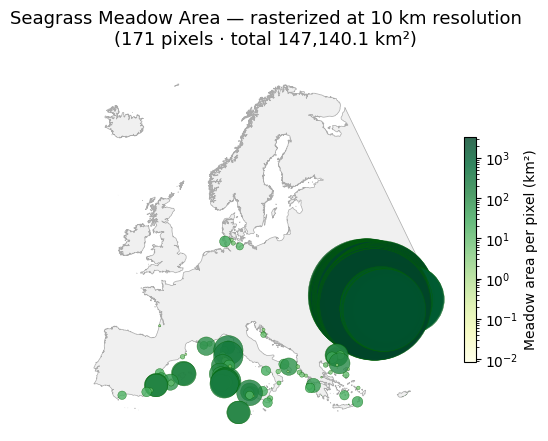

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd
import rasterio
from rasterio.transform import xy

# ── Read Europe boundary ──────────────────────────────────────────────────────
europe = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg")

# ── Read raster and extract non-zero pixel coordinates ───────────────────────
with rasterio.open(OUTPUT_PATH) as src:
    data = src.read(1).astype(np.float32)
    transform = src.transform
    raster_crs = src.crs

# Find non-zero pixels
rows, cols = np.where(data > 0)
values = data[rows, cols] / 1e6  # convert to km²

# Convert pixel indices to coordinates
xs, ys = xy(transform, rows, cols)
xs, ys = np.array(xs), np.array(ys)

print(f"Non-zero pixels: {len(values):,}")
print(f"Total area: {values.sum():,.1f} km²")

# ── Reproject Europe boundary to raster CRS if needed ────────────────────────
if europe.crs != raster_crs:
    europe = europe.to_crs(raster_crs)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(5,5))

# Europe base map
europe.plot(ax=ax, color="#f0f0f0", edgecolor="#aaaaaa", linewidth=0.5)

# Seagrass points, sized and coloured by area
norm = mcolors.LogNorm(vmin=values.min(), vmax=values.max())
cmap = plt.cm.YlGn

sc = ax.scatter(
    xs, ys,
    c=values,
    s=values * 2,        # size proportional to area
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    edgecolors="darkgreen",
    linewidths=0.3,
    zorder=3,
)

plt.colorbar(sc, ax=ax, label="Meadow area per pixel (km²)", shrink=0.5, pad=0.02)

ax.set_title("Seagrass Meadow Area — rasterized at 10 km resolution\n"
             f"({len(values):,} pixels · total {values.sum():,.1f} km²)", fontsize=13)
ax.set_axis_off()

plt.tight_layout()
plt.show()

### Seagrass density (incl. production) points

In [29]:
import pandas as pd
import requests
from io import StringIO

url = "https://doi.pangaea.de/10.1594/PANGAEA.929968?format=textfile"
content = requests.get(url).text

# Skip the comment block (everything between /* and */)
lines = content.split("\n")
data_start = next(i for i, line in enumerate(lines) if line.startswith("*/")) + 1
data_str = "\n".join(lines[data_start:])

df = pd.read_csv(StringIO(data_str), sep="\t")
print(df.shape)
print(df.columns.tolist())
df.head()

(6658, 18)
['Latitude', 'Longitude', 'Seagr bioregion', 'Habitat', 'Genus', 'Year obs [a AD]', 'Seagr biom above dm [g/m**2]', 'Seagr biom below dm [g/m**2]', 'Seagr biom tot dm [g/m**2]', 'Seagr shoot dens [#/m**2]', 'Seagr cov [%]', 'Seagr leaf dens [#/m**2]', 'Seagr prod above dm [g/m**2/day]', 'Seagr prod below dm [g/m**2/day]', 'Seagr prod total dm [g/m**2/day]', 'Seagr shoot prod dm [g/m**2/day]', 'Seagr leaf prod dm [g/m**2/day]', 'Reference']


,Latitude,Longitude,Seagr bioregion,Habitat,Genus,Year obs [a AD],Seagr biom above dm [g/m**2],Seagr biom below dm [g/m**2],Seagr biom tot dm [g/m**2],Seagr shoot dens [#/m**2],Seagr cov [%],Seagr leaf dens [#/m**2],Seagr prod above dm [g/m**2/day],Seagr prod below dm [g/m**2/day],Seagr prod total dm [g/m**2/day],Seagr shoot prod dm [g/m**2/day],Seagr leaf prod dm [g/m**2/day],Reference
0,42.561000,8.781000,Mediterranean,Coastal,Posidonia,2014.0,NaN,NaN,NaN,559.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abadie et al. 2019
1,42.561000,8.781000,Mediterranean,Coastal,Posidonia,2014.0,NaN,NaN,NaN,453.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abadie et al. 2019
2,42.561000,8.781000,Mediterranean,Coastal,Posidonia,2014.0,NaN,NaN,NaN,246.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Abadie et al. 2019
3,-2.266053,106.324451,Tropical Indo Pacific,Coastal,Cymodocea,2017.0,NaN,NaN,NaN,140.0,24.8,NaN,NaN,NaN,NaN,NaN,NaN,Adi et al. 2018
4,-2.270009,106.326637,Tropical Indo Pacific,Coastal,Cymodocea,2017.0,NaN,NaN,NaN,188.0,34.7,NaN,NaN,NaN,NaN,NaN,NaN,Adi et al. 2018


In [30]:
import geopandas as gpd
from shapely.geometry import Point

# ── Convert to GeoDataFrame ───────────────────────────────────────────────────
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

# ── Load Europe boundary and clip ─────────────────────────────────────────────
boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg").to_crs("EPSG:4326")
gdf_europe = gpd.clip(gdf, boundary)

print(f"Global points:  {len(gdf)}")
print(f"Europe points:  {len(gdf_europe)}")

# ── Reproject and save ────────────────────────────────────────────────────────
gdf_europe = gdf_europe.to_crs("EPSG:3035")
gdf_europe.to_file(
    "../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg",
    driver="GPKG"
)

Global points:  6658
Europe points:  1024


In [41]:
gdf_europe = gpd.read_file("../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg")
print(gdf_europe[[
    "Seagr biom above dm [g/m**2]",
    "Seagr biom below dm [g/m**2]",
    "Seagr biom tot dm [g/m**2]",
    "Seagr shoot dens [#/m**2]",
    "Seagr cov [%]",
    "Seagr leaf dens [#/m**2]",
    "Seagr prod above dm [g/m**2/day]",
    "Seagr prod below dm [g/m**2/day]",
    "Seagr prod total dm [g/m**2/day]",
    "Seagr shoot prod dm [g/m**2/day]",
    "Seagr leaf prod dm [g/m**2/day]",
]].notna().sum())

Seagr biom above dm [g/m**2]        532
Seagr biom below dm [g/m**2]        373
Seagr biom tot dm [g/m**2]          420
Seagr shoot dens [#/m**2]           683
Seagr cov [%]                       228
Seagr leaf dens [#/m**2]             47
Seagr prod above dm [g/m**2/day]     55
Seagr prod below dm [g/m**2/day]     48
Seagr prod total dm [g/m**2/day]     35
Seagr shoot prod dm [g/m**2/day]     40
Seagr leaf prod dm [g/m**2/day]     133
dtype: int64


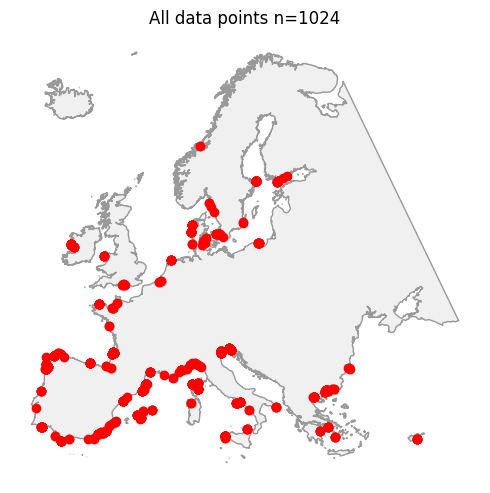

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
seagrass_data = gpd.read_file("../../data/processed/spatial_data/seagrass/seagrass_biomass_europe.gpkg")
europe_boundary = gpd.read_file("../../data/processed/spatial_data/europe_boundary.gpkg").to_crs(seagrass_data.crs)
column_name = f'All data points n={len(seagrass_data)}'
seagrass_data_filtered = seagrass_data # [seagrass_data[column_name].notna()]

fig, ax = plt.subplots(figsize=(5,5))
europe_boundary.plot(ax=ax, color="#f0f0f0", edgecolor="#999999")
seagrass_data_filtered.plot(ax=ax, color='red')
ax.set_title(f"{column_name}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [42]:
print('stats for "Seagr prod above dm [g/m**2/day]":')
print(gdf_europe[gdf_europe["Seagr prod above dm [g/m**2/day]"].notna()]["Seagr prod above dm [g/m**2/day]"].describe())

# print('\nstats for "Seagr biom above dm [g/m**2]": ')
# print(gdf_europe[gdf_europe["Seagr biom above dm [g/m**2]"].notna()]["Seagr biom above dm [g/m**2]"].describe())

stats for "Seagr prod above dm [g/m**2/day]":
count    55.000000
mean      5.311945
std       4.969570
min       0.085000
25%       1.200000
50%       3.630000
75%       8.527000
max      17.893000
Name: Seagr prod above dm [g/m**2/day], dtype: float64


### Beaches (to estimate where seagrass gets washed up)

#### backup - failed methods

Tried osm - download taking too long, too high resolution 

In [55]:
import osmnx as ox
import geopandas as gpd

# --- Paths ---
boundary_path = "../../data/processed/spatial_data/europe_boundary.gpkg"
output_path = "../../data/processed/spatial_data/beaches_europe.gpkg"

# --- Load and clean boundary ---
europe = gpd.read_file(boundary_path)
europe = europe[~europe.geometry.is_empty]
europe = europe[europe.geometry.notna()].copy()
europe["geometry"] = europe.geometry.make_valid()
europe_dissolved = europe.dissolve()

if europe_dissolved.crs != "EPSG:4326":
    europe_dissolved = europe_dissolved.to_crs("EPSG:4326")

print(f"Boundary CRS: {europe_dissolved.crs}")
print(f"Boundary valid: {europe_dissolved.geometry.is_valid.all()}")
print(f"Bounding box: {europe_dissolved.total_bounds}")

# --- Download beaches ---
ox.settings.overpass_settings = '[out:json][timeout:600][maxsize:1073741824]'

print("\nStarting download, this may take 5-15 minutes...")
beaches = ox.features_from_polygon(
    europe_dissolved.geometry.iloc[0],
    tags={"natural": "beach"}
)

print(f"Downloaded {len(beaches)} beach features")
print(beaches.geometry.geom_type.value_counts())

# --- Clip to exact boundary ---
beaches_clipped = gpd.clip(beaches, europe_dissolved)
print(f"After clipping: {len(beaches_clipped)} beach features")

# --- Save ---
beaches_clipped.to_file(output_path, driver="GPKG")
print(f"\nSaved to {output_path}")

Boundary CRS: EPSG:4326
Boundary valid: True
Bounding box: [-25.63635369  34.17130004  43.13118208  71.63181229]

Starting download, this may take 5-15 minutes...


/Users/tsuitpy/miniconda3/envs/geo_env/lib/python3.10/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 6,182 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


KeyboardInterrupt: 

Tried EMODNET - server is down

In [2]:
import geopandas as gpd

# Try downloading via WFS directly
wfs_url = (
    "https://drive.emodnet-geology.eu/geoserver/tno/wfs?"
    "SERVICE=WFS&VERSION=2.0.0&REQUEST=GetFeature"
    "&TYPENAMES=tno:coastal_type_20210501_010_250k_350k"
    "&OUTPUTFORMAT=application/json"
)

try:
    coastal_type = gpd.read_file(wfs_url)
    print(f"Downloaded {len(coastal_type)} features")
    print(coastal_type.columns.tolist())
    coastal_type.to_file("data/raw_data/spatial_data/emodnet_coastal_type.gpkg", driver="GPKG")
except Exception as e:
    print(f"WFS failed: {e}")

WFS failed: HTTP Error 400: 


#### Filter beach data

See link: https://zenodo.org/records/15607678

In [3]:
import geopandas as gpd

coastal = gpd.read_parquet("../../data/raw_data/spatial_data/seagrass/Europe_beaches.parquet")

# Basic checks
print(f"Number of features: {len(coastal)}")
print(f"CRS: {coastal.crs}")
print(f"\nColumns: {coastal.columns.tolist()}")
print(f"\nGeometry types: {coastal.geometry.geom_type.value_counts()}")

# Filter relevant data and save as GeoPackage
beaches = coastal[(coastal['class:coastal_type'] == 'sediment_plain') & (coastal['class:shore_type'] == 'sandy_gravel_or_small_boulder_sediments')]
beaches.to_file("../../data/processed/spatial_data/seagrass/beaches_europe.gpkg", driver="GPKG")

Number of features: 1778828
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": 

In [5]:
beaches.shape

(255748, 45)

### Make seagrass yield map (10x10km resolution)

#### Calculate m2 seagrass meadow per pixel

In [ ]:
# Step 2: Interpolate above-ground biomass point data (532 points, g DW m⁻²) onto the same raster grid → biomass density per pixel

# Step 3: Multiply meadow area × biomass density → total above-ground biomass [g DW] per pixel

# Step 4: Multiply by turnover rate (2.6% day⁻¹, Duarte & Chiscano 1999) × export fraction (0.28–0.50 Zostera, 0.40–0.65 Posidonia) × 365 → annual exported biomass [g DW yr⁻¹] per pixel

# Step 5: Rasterize beach locations → binary beach mask (1 = beach, 0 = no beach)

# Step 6: Multiply exported biomass raster × beach mask × deposition fraction (assumed, sensitivity range 0.2–0.6) → beach yield [g DW yr⁻¹] per pixel

## Climate data 

### Average temperature

In [44]:
import rasterio
import numpy as np
import os

data_dir = "../../data/raw_data/spatial_data/climate/wc2.1_10m_tavg"

files = sorted([f for f in os.listdir(data_dir) if f.endswith(".tif")])

print(f"{'File':<35} {'Min':>8} {'Max':>8} {'Mean':>8} {'NoData cells':>15}")
print("-" * 75)

for fname in files:
    fpath = os.path.join(data_dir, fname)
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        
        # Mask out nodata values
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            # WorldClim uses -32768 as nodata if not explicitly set
            data = np.where(data < -100, np.nan, data)
        
        valid = data[~np.isnan(data)]
        print(f"{fname:<35} {valid.min():>8.1f} {valid.max():>8.1f} {valid.mean():>8.1f} {np.isnan(data).sum():>15,}")

File                                     Min      Max     Mean    NoData cells
---------------------------------------------------------------------------
wc2.1_10m_tavg_01.tif                  -45.9     34.0     -6.7       1,524,747
wc2.1_10m_tavg_02.tif                  -44.8     32.8     -8.0       1,524,747
wc2.1_10m_tavg_03.tif                  -57.9     32.9     -8.2       1,524,747
wc2.1_10m_tavg_04.tif                  -64.2     34.2     -6.0       1,524,747
wc2.1_10m_tavg_05.tif                  -64.8     36.3     -3.1       1,524,747
wc2.1_10m_tavg_06.tif                  -64.4     38.4     -0.3       1,524,747
wc2.1_10m_tavg_07.tif                  -68.5     39.5      0.5       1,524,747
wc2.1_10m_tavg_08.tif                  -66.5     38.4     -0.3       1,524,747
wc2.1_10m_tavg_09.tif                  -64.6     35.8     -1.9       1,524,747
wc2.1_10m_tavg_10.tif                  -55.9     32.7     -3.8       1,524,747
wc2.1_10m_tavg_11.tif                  -43.4     32.8  

In [45]:
import rasterio
import rasterio.mask
import geopandas as gpd
import os

# Paths
input_dir = "../../data/raw_data/spatial_data/climate/wc2.1_10m_tavg"
boundary_path = "../../data/processed/spatial_data/europe_boundary.gpkg"
output_dir = "../../data/processed/spatial_data/climate"

os.makedirs(output_dir, exist_ok=True)

# Load European boundary
europe = gpd.read_file(boundary_path)

# Get list of tif files
files = sorted([f for f in os.listdir(input_dir) if f.endswith(".tif")])

for fname in files:
    input_path = os.path.join(input_dir, fname)
    output_path = os.path.join(output_dir, fname)  # keeps original filename

    with rasterio.open(input_path) as src:
        # Reproject boundary to match raster CRS if needed
        if europe.crs != src.crs:
            europe_reprojected = europe.to_crs(src.crs)
        else:
            europe_reprojected = europe

        # Crop to boundary
        cropped_data, cropped_transform = rasterio.mask.mask(
            src,
            europe_reprojected.geometry,
            crop=True,
            nodata=-32768
        )

        # Update metadata
        out_profile = src.profile.copy()
        out_profile.update({
            "height": cropped_data.shape[1],
            "width": cropped_data.shape[2],
            "transform": cropped_transform,
            "nodata": -32768
        })

        with rasterio.open(output_path, "w", **out_profile) as dst:
            dst.write(cropped_data)

    print(f"Saved: {fname}")

print("Done — all 12 months cropped to Europe.")

Saved: wc2.1_10m_tavg_01.tif
Saved: wc2.1_10m_tavg_02.tif
Saved: wc2.1_10m_tavg_03.tif
Saved: wc2.1_10m_tavg_04.tif
Saved: wc2.1_10m_tavg_05.tif
Saved: wc2.1_10m_tavg_06.tif
Saved: wc2.1_10m_tavg_07.tif
Saved: wc2.1_10m_tavg_08.tif
Saved: wc2.1_10m_tavg_09.tif
Saved: wc2.1_10m_tavg_10.tif
Saved: wc2.1_10m_tavg_11.tif
Saved: wc2.1_10m_tavg_12.tif
Done — all 12 months cropped to Europe.


### Water vapour pressure (kPa)

In [46]:
import rasterio
import rasterio.mask
import geopandas as gpd
import numpy as np
import os

# Paths
input_dir = "../../data/raw_data/spatial_data/climate/wc2.1_10m_vapr"
boundary_path = "../../data/processed/spatial_data/europe_boundary.gpkg"
output_dir = "../../data/processed/spatial_data/climate"

os.makedirs(output_dir, exist_ok=True)

# Load European boundary
europe = gpd.read_file(boundary_path)

# Get list of tif files
files = sorted([f for f in os.listdir(input_dir) if f.endswith(".tif")])

# --- Step 1: Check data quality ---
print("Data quality check:")
print(f"{'File':<35} {'Min':>8} {'Max':>8} {'Mean':>8} {'NoData cells':>15}")
print("-" * 75)

for fname in files:
    fpath = os.path.join(input_dir, fname)
    with rasterio.open(fpath) as src:
        data = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            data = np.where(data < -100, np.nan, data)

        valid = data[~np.isnan(data)]
        print(f"{fname:<35} {valid.min():>8.4f} {valid.max():>8.4f} {valid.mean():>8.4f} {np.isnan(data).sum():>15,}")

# --- Step 2: Crop to Europe and save ---
print("\nCropping to Europe:")

for fname in files:
    input_path = os.path.join(input_dir, fname)
    output_path = os.path.join(output_dir, fname)

    with rasterio.open(input_path) as src:
        if europe.crs != src.crs:
            europe_reprojected = europe.to_crs(src.crs)
        else:
            europe_reprojected = europe

        cropped_data, cropped_transform = rasterio.mask.mask(
            src,
            europe_reprojected.geometry,
            crop=True,
            nodata=-32768
        )

        out_profile = src.profile.copy()
        out_profile.update({
            "height": cropped_data.shape[1],
            "width": cropped_data.shape[2],
            "transform": cropped_transform,
            "nodata": -32768
        })

        with rasterio.open(output_path, "w", **out_profile) as dst:
            dst.write(cropped_data)

    print(f"Saved: {fname}")

print("\nDone — all 12 months checked and cropped to Europe.")

Data quality check:
File                                     Min      Max     Mean    NoData cells
---------------------------------------------------------------------------
wc2.1_10m_vapr_01.tif                 0.0000   3.3000   0.6033       1,524,747
wc2.1_10m_vapr_02.tif                 0.0000   3.2180   0.6027       1,524,747
wc2.1_10m_vapr_03.tif                 0.0000   3.2600   0.6305       1,524,747
wc2.1_10m_vapr_04.tif                 0.0000   3.3400   0.6911       1,524,747
wc2.1_10m_vapr_05.tif                 0.0000   3.4304   0.7847       1,524,747
wc2.1_10m_vapr_06.tif                 0.0000   3.4666   0.9146       1,524,747
wc2.1_10m_vapr_07.tif                 0.0000   3.5636   1.0231       1,524,747
wc2.1_10m_vapr_08.tif                 0.0000   3.5221   1.0009       1,524,747
wc2.1_10m_vapr_09.tif                 0.0000   3.5200   0.8752       1,524,747
wc2.1_10m_vapr_10.tif                 0.0000   3.2900   0.7390       1,524,747
wc2.1_10m_vapr_11.tif              

In [48]:
import rasterio
import rasterio.mask
import numpy as np
import os

# Paths
vapr_dir = "../../data/processed/spatial_data/climate"
tavg_dir = "../../data/processed/spatial_data/climate"
output_dir = "../../data/processed/spatial_data/climate"

os.makedirs(output_dir, exist_ok=True)

def saturation_vapour_pressure(temp_celsius):
    """Calculate saturation vapour pressure using the Magnus formula (kPa)."""
    return 0.6108 * np.exp(17.27 * temp_celsius / (temp_celsius + 237.3))

def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        profile = src.profile.copy()
        nodata = src.nodata
        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)
        else:
            data = np.where(data < -100, np.nan, data)
    return data, profile

print(f"{'File':<40} {'Min RH':>10} {'Max RH':>10} {'Mean RH':>10}")
print("-" * 75)

for month in range(1, 13):
    month_str = f"{month:02d}"

    vapr_path = os.path.join(vapr_dir, f"wc2.1_10m_vapr_{month_str}.tif")
    tavg_path = os.path.join(tavg_dir, f"wc2.1_10m_tavg_{month_str}.tif")
    output_path = os.path.join(output_dir, f"wc2.1_10m_rh_{month_str}.tif")

    # Load both rasters
    vapr, vapr_profile = load_raster(vapr_path)
    tavg, _ = load_raster(tavg_path)

    # Calculate relative humidity
    e_s = saturation_vapour_pressure(tavg)
    rh = (vapr / e_s) * 100

    # Clamp to physically valid range (0–100%)
    rh = np.clip(rh, 0, 100)

    # Restore nodata mask
    nodata_mask = np.isnan(vapr) | np.isnan(tavg)
    rh[nodata_mask] = -32768

    # Save output
    out_profile = vapr_profile.copy()
    out_profile.update({
        "dtype": "float32",
        "nodata": -32768
    })

    with rasterio.open(output_path, "w", **out_profile) as dst:
        dst.write(rh.astype("float32"), 1)

    # Print quality check (valid cells only)
    valid_rh = rh[rh != -32768]
    print(f"wc2.1_10m_rh_{month_str}.tif {valid_rh.min():>10.1f} {valid_rh.max():>10.1f} {valid_rh.mean():>10.1f}")

print("\nDone — relative humidity saved for all 12 months.")

File                                         Min RH     Max RH    Mean RH
---------------------------------------------------------------------------
wc2.1_10m_rh_01.tif       40.8      100.0       83.7
wc2.1_10m_rh_02.tif       48.0      100.0       81.4
wc2.1_10m_rh_03.tif       55.9      100.0       76.6
wc2.1_10m_rh_04.tif       54.4       95.8       71.0
wc2.1_10m_rh_05.tif       48.1       95.5       68.0
wc2.1_10m_rh_06.tif       42.3      100.0       69.1
wc2.1_10m_rh_07.tif       39.1      100.0       70.3
wc2.1_10m_rh_08.tif       41.8      100.0       72.0
wc2.1_10m_rh_09.tif       45.4      100.0       76.2
wc2.1_10m_rh_10.tif       48.0       96.8       80.1
wc2.1_10m_rh_11.tif       55.4      100.0       84.7
wc2.1_10m_rh_12.tif       41.1      100.0       84.7

Done — relative humidity saved for all 12 months.


### Aggregate to Europe raster

In [38]:
"""
Aggregate WorldClim monthly climate data to the Europe 10km reference grid.

Extracts January (coldest) and July (hottest) for:
  - Average temperature (°C)
  - Relative humidity (%)

Reprojects and resamples both to match europe_boundary_10km.tif exactly.

Outputs:
  europe_10km_temperature_degC_Jan_Jul.tif   (band 1 = Jan, band 2 = Jul)
  europe_10km_relative_humidity_pct_Jan_Jul.tif  (band 1 = Jan, band 2 = Jul)
"""

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

# ── Config ────────────────────────────────────────────────────────────────────

CLIMATE_DIR = "../../data/processed/spatial_data/climate"
OUT_DIR     = "../../data/processed/spatial_data/climate"
REF_PATH    = "../../data/processed/spatial_data/europe_boundary_10km.tif"

MONTHS = {"Jan": "01", "Jul": "07"}

VARIABLES = {
    "temperature_degC":    "wc2.1_10m_tavg",
    "relative_humidity_pct": "wc2.1_10m_rh",
}

# ── Load reference grid ───────────────────────────────────────────────────────

print("Loading reference grid …")
with rasterio.open(REF_PATH) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_width     = ref.width
    ref_height    = ref.height

print(f"  CRS: {ref_crs}")
print(f"  Size: {ref_width} × {ref_height} px\n")

# ── Process each variable ─────────────────────────────────────────────────────

for var_name, file_prefix in VARIABLES.items():
    out_path = f"{OUT_DIR}/europe_10km_{var_name}_Jan_Jul.tif"
    print(f"── {var_name} ──────────────────────────────────────────")

    bands = []

    for month_name, month_num in MONTHS.items():
        src_path = f"{CLIMATE_DIR}/{file_prefix}_{month_num}.tif"
        print(f"  Reading {month_name} ({src_path.split('/')[-1]}) …")

        with rasterio.open(src_path) as src:
            data      = src.read(1).astype(np.float32)
            src_crs   = src.crs
            src_trans = src.transform
            nodata    = src.nodata

        if nodata is not None:
            data = np.where(data == nodata, np.nan, data)

        # Reproject to reference grid using bilinear resampling (appropriate
        # for continuous variables like temperature and humidity)
        dst_data = np.full((ref_height, ref_width), np.nan, dtype=np.float32)

        reproject(
            source        = data,
            destination   = dst_data,
            src_transform = src_trans,
            src_crs       = src_crs,
            src_nodata    = np.nan,
            dst_transform = ref_transform,
            dst_crs       = ref_crs,
            dst_nodata    = np.nan,
            resampling    = Resampling.bilinear,
        )

        valid = int(np.sum(~np.isnan(dst_data)))
        print(f"    mean={np.nanmean(dst_data):.2f}  min={np.nanmin(dst_data):.2f}"
              f"  max={np.nanmax(dst_data):.2f}  valid pixels={valid:,}")

        bands.append(dst_data)

    # ── Write 2-band GeoTIFF ──────────────────────────────────────────────────
    out_profile = {
        "driver":    "GTiff",
        "dtype":     "float32",
        "width":     ref_width,
        "height":    ref_height,
        "count":     2,
        "crs":       ref_crs,
        "transform": ref_transform,
        "nodata":    -9999.0,
        "compress":  "lzw",
        "tiled":     True,
        "blockxsize": 256,
        "blockysize": 256,
    }

    out_bands = [np.where(np.isnan(b), -9999.0, b).astype(np.float32) for b in bands]

    with rasterio.open(out_path, "w", **out_profile) as dst:
        dst.write(out_bands[0], 1)
        dst.write(out_bands[1], 2)
        dst.update_tags(
            band_1      = "January (coldest month)",
            band_2      = "July (hottest month)",
            variable    = var_name,
            source      = "WorldClim 2.1 10m",
            grid        = "Aligned to europe_boundary_10km.tif",
        )
        dst.update_tags(1, month="January", month_num="01")
        dst.update_tags(2, month="July",    month_num="07")

    print(f"  Saved → {out_path}\n")

print("Done.")

Loading reference grid …
  CRS: EPSG:3035
  Size: 421 × 404 px

── temperature_degC ──────────────────────────────────────────
  Reading Jan (wc2.1_10m_tavg_01.tif) …
    mean=-2.39  min=-16.25  max=14.10  valid pixels=82,442
  Reading Jul (wc2.1_10m_tavg_07.tif) …
    mean=17.87  min=1.01  max=28.53  valid pixels=82,442
  Saved → ../../data/processed/spatial_data/climate/europe_10km_temperature_degC_Jan_Jul.tif

── relative_humidity_pct ──────────────────────────────────────────
  Reading Jan (wc2.1_10m_rh_01.tif) …
    mean=83.22  min=44.84  max=100.00  valid pixels=82,442
  Reading Jul (wc2.1_10m_rh_07.tif) …
    mean=69.36  min=39.29  max=98.87  valid pixels=82,442
  Saved → ../../data/processed/spatial_data/climate/europe_10km_relative_humidity_pct_Jan_Jul.tif

Done.


### Plot maps

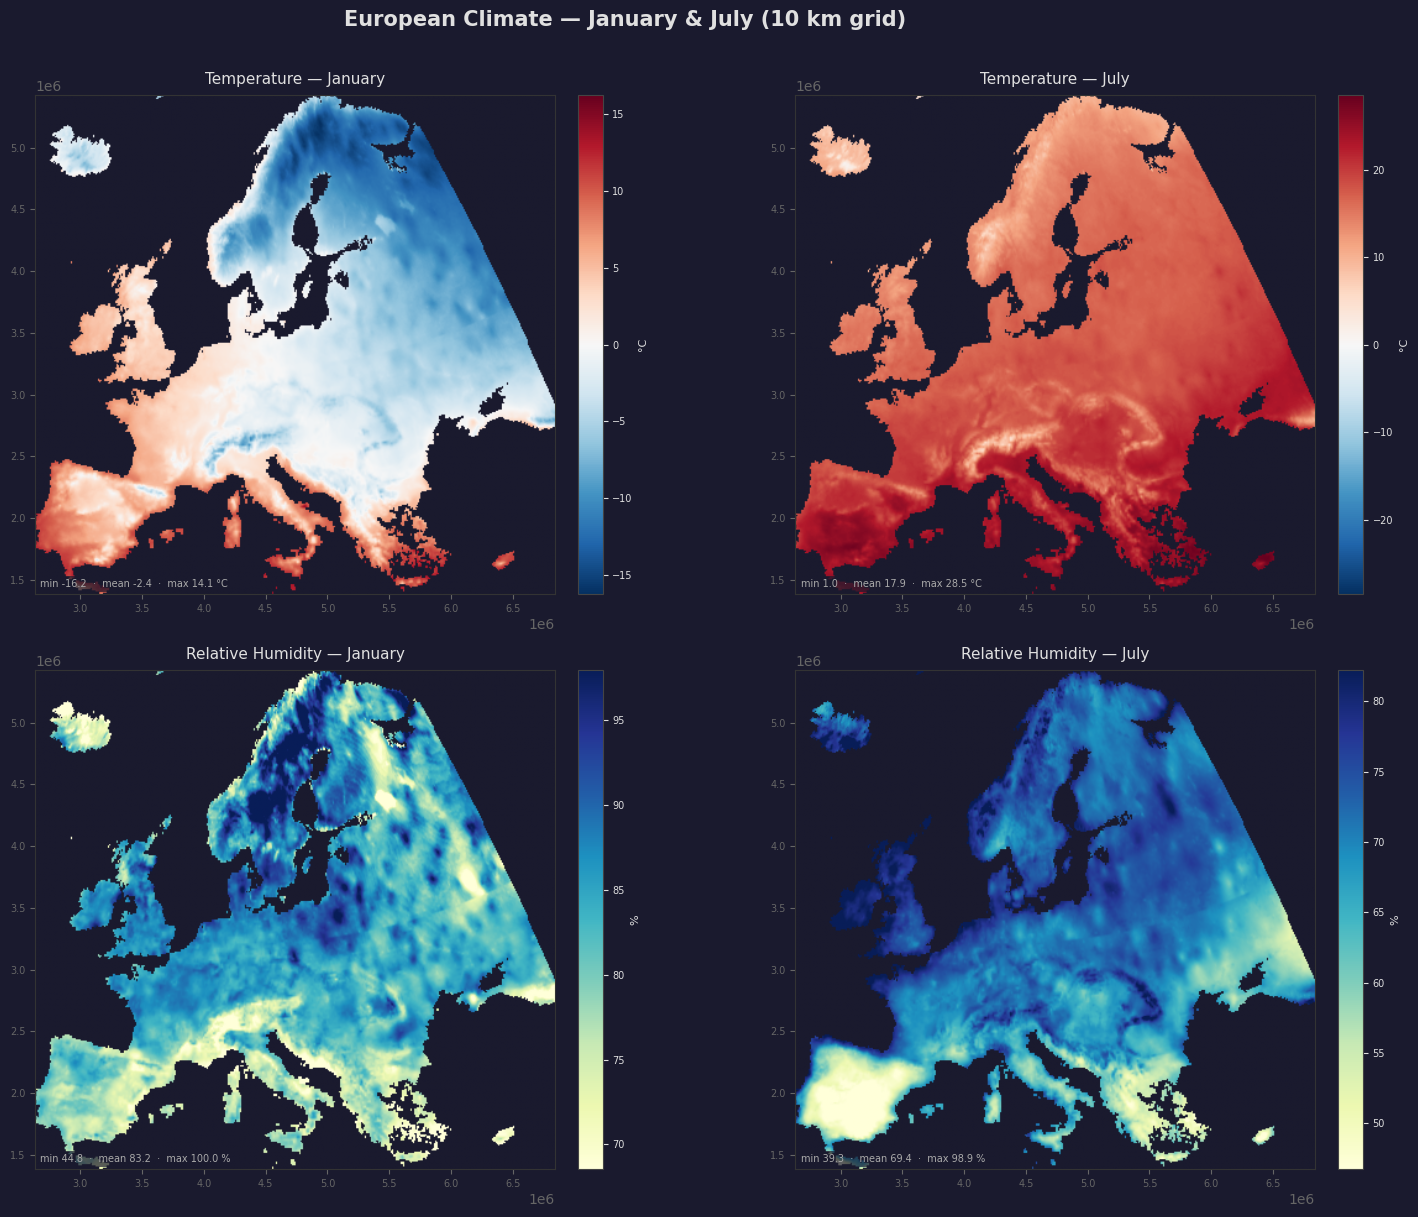

In [40]:
"""
Visualize January and July climate data: temperature and relative humidity.
Four panels in a 2x2 grid.
"""

import numpy as np
import rasterio
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────

CLIMATE_DIR = "../../data/processed/spatial_data/climate"

FILES = {
    "temp":  f"{CLIMATE_DIR}/europe_10km_temperature_degC_Jan_Jul.tif",
    "humid": f"{CLIMATE_DIR}/europe_10km_relative_humidity_pct_Jan_Jul.tif",
}

PANELS = [
    {"file": "temp",  "band": 1, "title": "Temperature — January", "cmap": "RdBu_r", "unit": "°C"},
    {"file": "temp",  "band": 2, "title": "Temperature — July",    "cmap": "RdBu_r", "unit": "°C"},
    {"file": "humid", "band": 1, "title": "Relative Humidity — January", "cmap": "YlGnBu", "unit": "%"},
    {"file": "humid", "band": 2, "title": "Relative Humidity — July",    "cmap": "YlGnBu", "unit": "%"},
]

BG_COLOR   = "#1a1a2e"
TEXT_COLOR = "#e0e0e0"

# ── Load data ─────────────────────────────────────────────────────────────────

loaded = {}
for key, path in FILES.items():
    with rasterio.open(path) as src:
        loaded[key] = {
            "bands":  [src.read(b).astype(float) for b in (1, 2)],
            "bounds": src.bounds,
            "nodata": src.nodata,
        }
    for band in loaded[key]["bands"]:
        if loaded[key]["nodata"] is not None:
            band[band == loaded[key]["nodata"]] = np.nan

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=BG_COLOR)
fig.suptitle("European Climate — January & July (10 km grid)",
             color=TEXT_COLOR, fontsize=15, fontweight="bold", y=1.01)

for ax, panel in zip(axes.flat, PANELS):
    ds     = loaded[panel["file"]]
    data   = ds["bands"][panel["band"] - 1]
    bounds = ds["bounds"]
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    # Symmetric colour scale for temperature (so 0°C is always white/neutral)
    if panel["file"] == "temp":
        vabs = np.nanmax(np.abs(data))
        vmin, vmax = -vabs, vabs
    else:
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)

    cmap = plt.get_cmap(panel["cmap"]).copy()
    cmap.set_bad(color=BG_COLOR)

    im = ax.imshow(
        data,
        extent=extent,
        origin="upper",
        cmap=cmap,
        interpolation="bilinear",
        vmin=vmin,
        vmax=vmax,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR, labelsize=7)
    cbar.outline.set_edgecolor("#444444")
    cbar.set_label(panel["unit"], color=TEXT_COLOR, fontsize=8)

    stats = (f"min {np.nanmin(data):.1f}  ·  "
             f"mean {np.nanmean(data):.1f}  ·  "
             f"max {np.nanmax(data):.1f} {panel['unit']}")
    ax.text(0.01, 0.01, stats, transform=ax.transAxes,
            color="#aaaaaa", fontsize=7, va="bottom",
            bbox=dict(facecolor=BG_COLOR, edgecolor="none", alpha=0.7, pad=2))

    ax.set_title(panel["title"], color=TEXT_COLOR, fontsize=11, pad=8)
    ax.set_facecolor(BG_COLOR)
    ax.tick_params(colors="#666666", labelsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

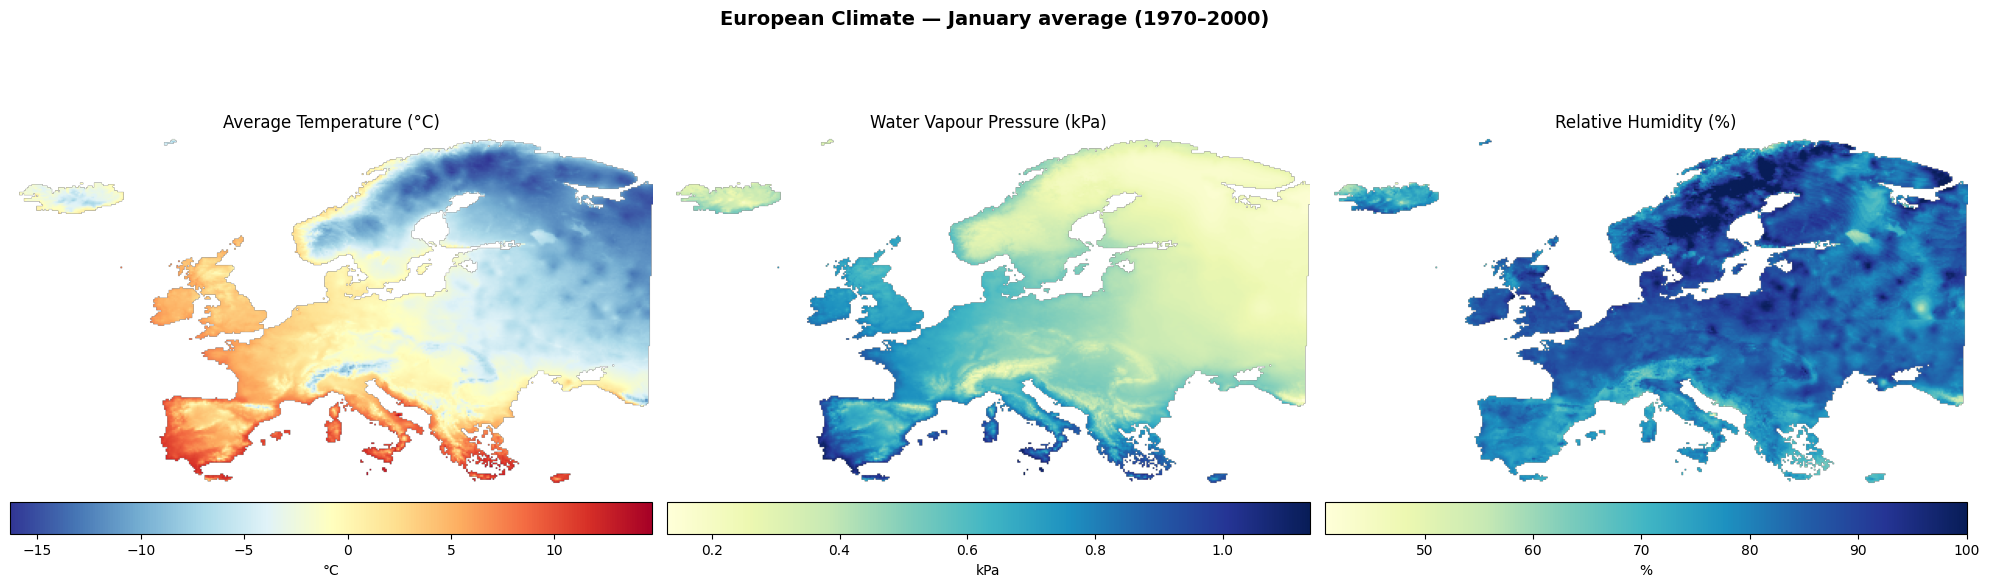

In [50]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Paths
tavg_path = "../../data/processed/spatial_data/climate/wc2.1_10m_tavg_01.tif"
vapr_path = "../../data/processed/spatial_data/climate/wc2.1_10m_vapr_01.tif"
rh_path   = "../../data/processed/spatial_data/climate/wc2.1_10m_rh_01.tif"

# Load data
def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        data = np.where(data < -100, np.nan, data)
    return data

tavg = load_raster(tavg_path)
vapr = load_raster(vapr_path)
rh   = load_raster(rh_path)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("European Climate — January average (1970–2000)", fontsize=14, fontweight="bold")

layers = [
    (tavg, "Average Temperature (°C)",    "RdYlBu_r", "°C"),
    (vapr, "Water Vapour Pressure (kPa)", "YlGnBu",   "kPa"),
    (rh,   "Relative Humidity (%)",       "YlGnBu",   "%"),
]

for ax, (data, title, cmap, label) in zip(axes, layers):
    # Derive vmin and vmax from actual data range
    vmin = np.nanmin(data)
    vmax = np.nanmax(data)

    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.axis("off")
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, label=label)

plt.tight_layout()
plt.show()